In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

print("All libraries imported")

All libraries imported


In [2]:
df = pd.read_csv("spam.csv",encoding='latin-1')
df = df[['v1','v2']].copy()
df.columns = ['label','message']

In [3]:
print("Shape:",df.shape)
print()
print(df['label'].value_counts())

Shape: (5572, 2)

label
ham     4825
spam     747
Name: count, dtype: int64


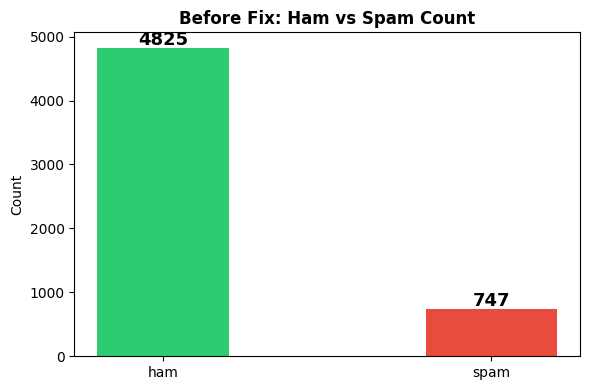

Ham  : 4825  (86.6%)
Spam : 747 (13.4%)


In [4]:
counts = df['label'].value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], width=0.4)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 40,
             str(val), ha='center', fontweight='bold', fontsize=13)

plt.title('Before Fix: Ham vs Spam Count', fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Ham  : {counts['ham']}  ({counts['ham']/len(df)*100:.1f}%)")
print(f"Spam : {counts['spam']} ({counts['spam']/len(df)*100:.1f}%)")

In [5]:
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
print("Train size:", len(X_train))
print("Test  size:", len(X_test))
print()
print("Spam in train:", sum(y_train == 'spam'))
print("Ham  in train:", sum(y_train == 'ham'))

Train size: 4457
Test  size: 1115

Spam in train: 597
Ham  in train: 3860


In [8]:
oversampler = RandomOverSampler(random_state=42)

X_train_raw_2d = X_train.to_numpy().reshape(-1, 1) 
X_resampled_2d, y_train_resampled = oversampler.fit_resample(X_train_raw_2d, y_train)
X_train_resampled = X_resampled_2d.flatten()

In [9]:
print("BEFORE oversampling:")
print("  Ham :", sum(y_train == 'ham'))
print("  Spam:", sum(y_train == 'spam'))
print()
print("AFTER oversampling:")
print("  Ham :", sum(y_train_resampled == 'ham'))
print("  Spam:", sum(y_train_resampled == 'spam'))

BEFORE oversampling:
  Ham : 3860
  Spam: 597

AFTER oversampling:
  Ham : 3860
  Spam: 3860


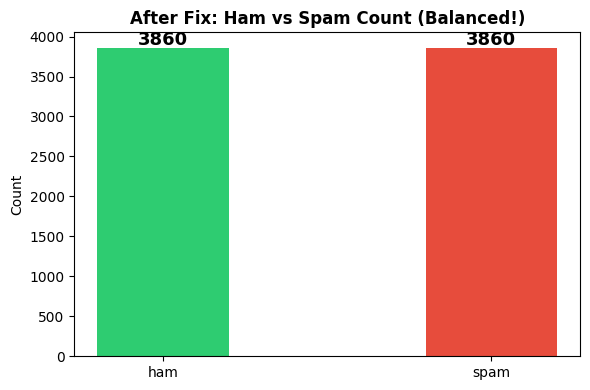

In [10]:
after_counts = pd.Series(y_train_resampled).value_counts()

plt.figure(figsize=(6, 4))
bars = plt.bar(after_counts.index, after_counts.values, color=['#2ecc71', '#e74c3c'], width=0.4)
for bar, val in zip(bars, after_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 40,
             str(val), ha='center', fontweight='bold', fontsize=13)

plt.title('After Fix: Ham vs Spam Count (Balanced!)', fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
tfidf = TfidfVectorizer(max_features=3000)

X_train_tfidf = tfidf.fit_transform(X_train_resampled)
X_test_tfidf = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test  shape:", X_test_tfidf.shape)
print("Both must have the same second number ✅")

Train shape: (7720, 3000)
Test  shape: (1115, 3000)
Both must have the same second number ✅


In [12]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train_resampled)

print("Model trained successfully!")

Model trained successfully!


In [13]:
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.98       965
        spam       0.91      0.89      0.90       150

    accuracy                           0.97      1115
   macro avg       0.94      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115



<Figure size 500x400 with 0 Axes>

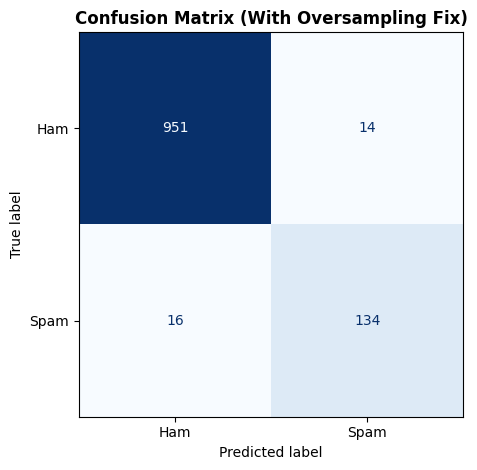

Spam caught : 134
Spam missed : 16


In [14]:
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])

plt.figure(figsize=(5, 4))
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion Matrix (With Oversampling Fix)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Spam caught : {cm[1][1]}")
print(f"Spam missed : {cm[1][0]}")

In [15]:
def predict(message):
    msg_tfidf = tfidf.transform([message])
    result = model.predict(msg_tfidf)[0]
    return result

test_messages = [
    "Congratulations! You won a FREE iPhone. Call now to claim your prize!",
    "Hey, are you coming to dinner tonight?",
    "URGENT: Your bank account has been suspended. Call 0800123456",
    "Can you bring milk from the store please?",
    "Win £1000 cash! Text WIN to 87122 now. Free entry.",
]

print(f"{'Message':<52} Result")
print("─" * 65)
for msg in test_messages:
    result = predict(msg)
    icon = "🔴 SPAM" if result == 'spam' else "🟢 HAM"
    short = msg[:50] + '..' if len(msg) > 52 else msg
    print(f"{short:<52} {icon}")

Message                                              Result
─────────────────────────────────────────────────────────────────
Congratulations! You won a FREE iPhone. Call now t.. 🔴 SPAM
Hey, are you coming to dinner tonight?               🟢 HAM
URGENT: Your bank account has been suspended. Call.. 🔴 SPAM
Can you bring milk from the store please?            🟢 HAM
Win £1000 cash! Text WIN to 87122 now. Free entry.   🔴 SPAM


In [16]:
import pickle

with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("spam_tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("Model saved successfully!")

Model saved successfully!
